
# Assignment 10 — Comparing GAN and VAE Using Experimental Results

This notebook compares the **DCGAN from Assignment 4** and the **2D VAE from Assignment 8** using their generated outputs.

The comparison covers:
- Image sharpness
- Diversity
- Realism
- Training stability
- Ease of controlling the output
- Risk of mode collapse
- Typical applications

The notebook also displays approximately **8 generated images from each model** and provides a comparison table and final-verdict section.



## Source models used

**Assignment 4 — DCGAN**
- Dataset: Fashion-MNIST
- Latent dimension: 100
- Batch size: 128
- Learning rate: 0.0002
- Training: 25 epochs
- Generator: ConvTranspose2d + BatchNorm + ReLU + Tanh
- Discriminator: Conv2d + BatchNorm + LeakyReLU + Sigmoid

**Assignment 8 — VAE**
- Dataset: MNIST
- Latent dimension: 2
- Batch size: 128
- Learning rate: 0.001
- Training: 20 epochs
- Encoder/decoder: fully connected layers
- Latent space: 2-dimensional


In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu130
Device: cuda
GPU: Tesla T4


## 1. Load the Datasets

In [2]:
# Fashion-MNIST for the DCGAN
gan_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

gan_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=gan_transform
)

gan_loader = DataLoader(
    gan_dataset,
    batch_size=128,
    shuffle=True
)


# MNIST for the VAE
vae_transform = transforms.ToTensor()

vae_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=vae_transform
)

vae_loader = DataLoader(
    vae_dataset,
    batch_size=128,
    shuffle=True
)

print("Fashion-MNIST images:", len(gan_dataset))
print("MNIST images:", len(vae_dataset))


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.17MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.6MB/s]
100%|██████████| 9.91M/9.91M [00:01<00:00, 4.96MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]

Fashion-MNIST images: 60000
MNIST images: 60000


## 2. Define the Assignment 4 DCGAN

In [3]:
LATENT_DIM_GAN = 100
GAN_EPOCHS = 25
GAN_LR = 0.0002


class Generator(nn.Module):

    def __init__(self, latent_dim):
        super(Generator, self).__init__()

        self.model = nn.Sequential(

            nn.ConvTranspose2d(
                latent_dim,
                128,
                kernel_size=7,
                stride=1,
                padding=0
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(
                64,
                1,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.Tanh()
        )

    def forward(self, noise):
        return self.model(noise)


class Discriminator(nn.Module):

    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(

            nn.Conv2d(
                1,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.LeakyReLU(0.2),

            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(
                128,
                1,
                kernel_size=7,
                stride=1,
                padding=0
            ),

            nn.Sigmoid()
        )

    def forward(self, image):
        return self.model(image).view(-1)


## 3. Train the DCGAN

In [4]:
generator = Generator(
    LATENT_DIM_GAN
).to(device)

discriminator = Discriminator().to(device)

criterion_gan = nn.BCELoss()

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=GAN_LR,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=GAN_LR,
    betas=(0.5, 0.999)
)

generator_losses = []
discriminator_losses = []

torch.manual_seed(42)

fixed_noise = torch.randn(
    16,
    LATENT_DIM_GAN,
    1,
    1,
    device=device
)


for epoch in range(1, GAN_EPOCHS + 1):

    total_g_loss = 0.0
    total_d_loss = 0.0

    for real_images, _ in gan_loader:

        real_images = real_images.to(device)

        current_batch_size = real_images.size(0)

        real_labels = torch.ones(
            current_batch_size,
            device=device
        )

        fake_labels = torch.zeros(
            current_batch_size,
            device=device
        )

        # -------------------------
        # Train Discriminator
        # -------------------------

        optimizer_D.zero_grad()

        real_output = discriminator(
            real_images
        )

        real_loss = criterion_gan(
            real_output,
            real_labels
        )

        noise = torch.randn(
            current_batch_size,
            LATENT_DIM_GAN,
            1,
            1,
            device=device
        )

        fake_images = generator(noise)

        fake_output = discriminator(
            fake_images.detach()
        )

        fake_loss = criterion_gan(
            fake_output,
            fake_labels
        )

        d_loss = real_loss + fake_loss

        d_loss.backward()
        optimizer_D.step()

        # -------------------------
        # Train Generator
        # -------------------------

        optimizer_G.zero_grad()

        noise = torch.randn(
            current_batch_size,
            LATENT_DIM_GAN,
            1,
            1,
            device=device
        )

        fake_images = generator(noise)

        output = discriminator(
            fake_images
        )

        g_loss = criterion_gan(
            output,
            real_labels
        )

        g_loss.backward()
        optimizer_G.step()

        total_d_loss += d_loss.item()
        total_g_loss += g_loss.item()

    avg_d_loss = total_d_loss / len(gan_loader)
    avg_g_loss = total_g_loss / len(gan_loader)

    discriminator_losses.append(avg_d_loss)
    generator_losses.append(avg_g_loss)

    print(
        "Epoch [{}/{}] | D Loss: {:.4f} | G Loss: {:.4f}".format(
            epoch,
            GAN_EPOCHS,
            avg_d_loss,
            avg_g_loss
        )
    )


Epoch [1/25] | D Loss: 0.6558 | G Loss: 1.7267
Epoch [2/25] | D Loss: 0.8278 | G Loss: 1.3912
Epoch [3/25] | D Loss: 0.9619 | G Loss: 1.2291
Epoch [4/25] | D Loss: 1.0236 | G Loss: 1.1443
Epoch [5/25] | D Loss: 1.0332 | G Loss: 1.1395
Epoch [6/25] | D Loss: 1.0310 | G Loss: 1.1417
Epoch [7/25] | D Loss: 1.0335 | G Loss: 1.1449
Epoch [8/25] | D Loss: 1.0288 | G Loss: 1.1615
Epoch [9/25] | D Loss: 1.0188 | G Loss: 1.1691
Epoch [10/25] | D Loss: 1.0142 | G Loss: 1.1899
Epoch [11/25] | D Loss: 1.0117 | G Loss: 1.1895
Epoch [12/25] | D Loss: 1.0080 | G Loss: 1.2083
Epoch [13/25] | D Loss: 1.0013 | G Loss: 1.2166
Epoch [14/25] | D Loss: 0.9963 | G Loss: 1.2225
Epoch [15/25] | D Loss: 0.9864 | G Loss: 1.2414
Epoch [16/25] | D Loss: 0.9684 | G Loss: 1.2579
Epoch [17/25] | D Loss: 0.9692 | G Loss: 1.2718
Epoch [18/25] | D Loss: 0.9490 | G Loss: 1.2947
Epoch [19/25] | D Loss: 0.9415 | G Loss: 1.3131
Epoch [20/25] | D Loss: 0.9348 | G Loss: 1.3188
Epoch [21/25] | D Loss: 0.9265 | G Loss: 1.3493
E

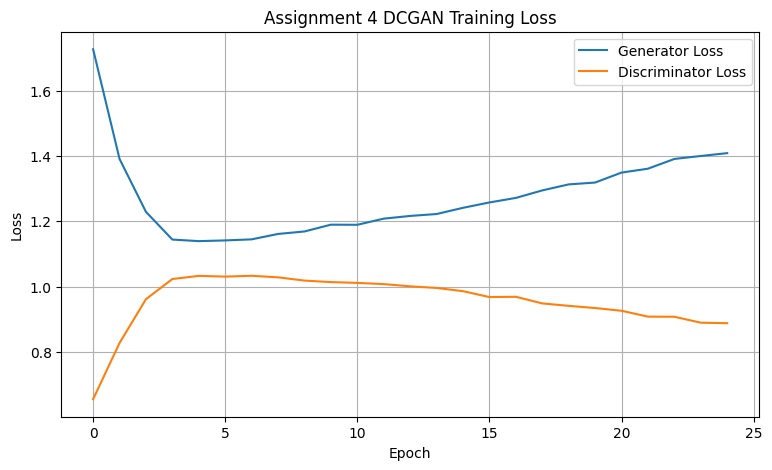

In [5]:
# Plot GAN training stability

plt.figure(figsize=(9, 5))

plt.plot(
    generator_losses,
    label="Generator Loss"
)

plt.plot(
    discriminator_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Assignment 4 DCGAN Training Loss")
plt.legend()
plt.grid(True)
plt.show()


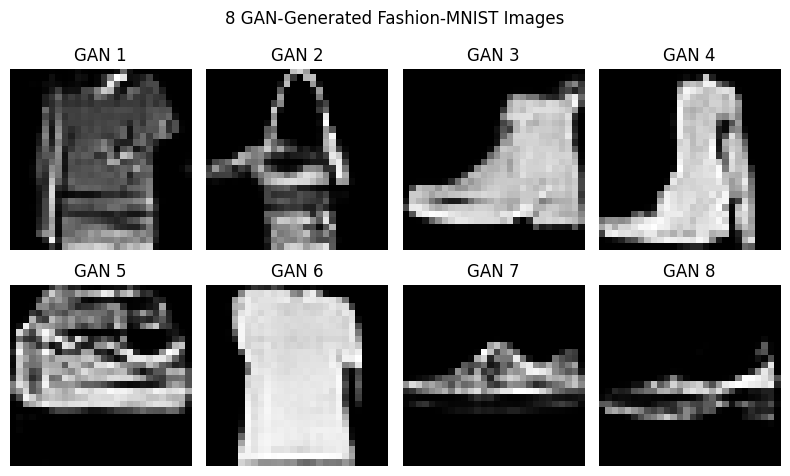

In [6]:
# Generate 8 final GAN samples

generator.eval()

with torch.no_grad():
    gan_generated = generator(
        fixed_noise[:8]
    ).cpu()

generator.train()


fig, axes = plt.subplots(
    2,
    4,
    figsize=(8, 5)
)

for i, ax in enumerate(axes.flatten()):

    image = (gan_generated[i] + 1) / 2

    ax.imshow(
        image.squeeze(),
        cmap="gray"
    )

    ax.set_title(
        "GAN {}".format(i + 1)
    )

    ax.axis("off")

plt.suptitle(
    "8 GAN-Generated Fashion-MNIST Images"
)

plt.tight_layout()
plt.show()


## 4. Define the Assignment 8 VAE

In [7]:
LATENT_DIM_VAE = 2
VAE_EPOCHS = 20
VAE_LR = 0.001


class VAE(nn.Module):

    def __init__(self, latent_dim=2):
        super().__init__()

        self.fc1 = nn.Linear(
            784,
            256
        )

        self.fc_mu = nn.Linear(
            256,
            latent_dim
        )

        self.fc_logvar = nn.Linear(
            256,
            latent_dim
        )

        self.fc2 = nn.Linear(
            latent_dim,
            256
        )

        self.fc3 = nn.Linear(
            256,
            784
        )

    def encode(self, x):

        h = F.relu(
            self.fc1(x)
        )

        return (
            self.fc_mu(h),
            self.fc_logvar(h)
        )

    def reparameterize(
        self,
        mu,
        logvar
    ):

        std = torch.exp(
            0.5 * logvar
        )

        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):

        return torch.sigmoid(
            self.fc3(
                F.relu(
                    self.fc2(z)
                )
            )
        )

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(
            mu,
            logvar
        )

        return (
            self.decode(z),
            mu,
            logvar
        )


def vae_loss(
    reconstruction,
    x,
    mu,
    logvar
):

    reconstruction_loss = F.binary_cross_entropy(
        reconstruction,
        x,
        reduction="sum"
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar -
        mu.pow(2) -
        logvar.exp()
    )

    return (
        reconstruction_loss +
        kl_loss,
        reconstruction_loss,
        kl_loss
    )


## 5. Train the VAE

In [8]:
vae = VAE(
    LATENT_DIM_VAE
).to(device)

optimizer_vae = optim.Adam(
    vae.parameters(),
    lr=VAE_LR
)

vae_reconstruction_losses = []
vae_kl_losses = []

for epoch in range(1, VAE_EPOCHS + 1):

    vae.train()

    total_recon = 0.0
    total_kl = 0.0

    for images, _ in vae_loader:

        images = images.to(device)

        images = images.view(
            images.size(0),
            -1
        )

        optimizer_vae.zero_grad()

        reconstruction, mu, logvar = vae(
            images
        )

        loss, recon, kl = vae_loss(
            reconstruction,
            images,
            mu,
            logvar
        )

        loss.backward()
        optimizer_vae.step()

        total_recon += recon.item()
        total_kl += kl.item()

    n = len(vae_loader.dataset)

    avg_recon = total_recon / n
    avg_kl = total_kl / n

    vae_reconstruction_losses.append(
        avg_recon
    )

    vae_kl_losses.append(
        avg_kl
    )

    print(
        "Epoch [{}/{}] | Reconstruction: {:.4f} | KL: {:.4f}".format(
            epoch,
            VAE_EPOCHS,
            avg_recon,
            avg_kl
        )
    )


Epoch [1/20] | Reconstruction: 189.5638 | KL: 6.3405
Epoch [2/20] | Reconstruction: 165.8834 | KL: 5.0597
Epoch [3/20] | Reconstruction: 161.0904 | KL: 5.1475
Epoch [4/20] | Reconstruction: 158.4373 | KL: 5.2263
Epoch [5/20] | Reconstruction: 156.5740 | KL: 5.3033
Epoch [6/20] | Reconstruction: 155.0317 | KL: 5.3817
Epoch [7/20] | Reconstruction: 153.6344 | KL: 5.4510
Epoch [8/20] | Reconstruction: 152.2900 | KL: 5.5432
Epoch [9/20] | Reconstruction: 151.0975 | KL: 5.6349
Epoch [10/20] | Reconstruction: 150.0488 | KL: 5.7243
Epoch [11/20] | Reconstruction: 149.1253 | KL: 5.7759
Epoch [12/20] | Reconstruction: 148.2725 | KL: 5.8368
Epoch [13/20] | Reconstruction: 147.5922 | KL: 5.8745
Epoch [14/20] | Reconstruction: 146.9973 | KL: 5.9346
Epoch [15/20] | Reconstruction: 146.4181 | KL: 5.9656
Epoch [16/20] | Reconstruction: 145.9287 | KL: 5.9962
Epoch [17/20] | Reconstruction: 145.5442 | KL: 6.0150
Epoch [18/20] | Reconstruction: 145.1192 | KL: 6.0461
Epoch [19/20] | Reconstruction: 144.7

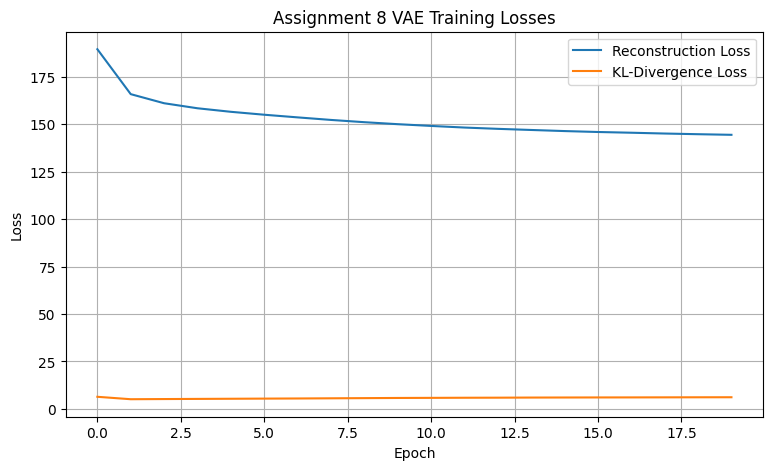

In [9]:
# Plot VAE training stability

plt.figure(figsize=(9, 5))

plt.plot(
    vae_reconstruction_losses,
    label="Reconstruction Loss"
)

plt.plot(
    vae_kl_losses,
    label="KL-Divergence Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Assignment 8 VAE Training Losses")
plt.legend()
plt.grid(True)
plt.show()


## 6. Generate 8 VAE Images

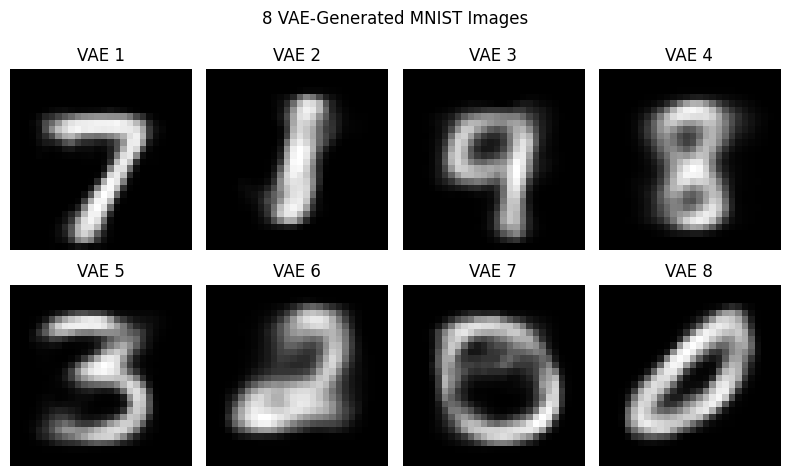

In [10]:
vae.eval()

# Use eight points in the learned 2D latent space.
vae_latent_points = torch.tensor(
    [
        [-2.5, -2.0],
        [-1.5,  1.0],
        [-0.5, -1.5],
        [ 0.0,  0.0],
        [ 0.5,  1.5],
        [ 1.0, -0.5],
        [ 1.8,  1.5],
        [ 2.5, -1.0]
    ],
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    vae_generated = vae.decode(
        vae_latent_points
    ).cpu()

vae_generated = vae_generated.view(
    8,
    1,
    28,
    28
)


fig, axes = plt.subplots(
    2,
    4,
    figsize=(8, 5)
)

for i, ax in enumerate(axes.flatten()):

    ax.imshow(
        vae_generated[i].squeeze(),
        cmap="gray"
    )

    ax.set_title(
        "VAE {}".format(i + 1)
    )

    ax.axis("off")

plt.suptitle(
    "8 VAE-Generated MNIST Images"
)

plt.tight_layout()
plt.show()


## 7. Optional Quantitative Proxies


The assignment is primarily a qualitative comparison. The following values are only **supporting measurements**:

- A simple image-gradient measure is used as a sharpness proxy.
- Mean pairwise pixel distance is used as a diversity proxy.

These values should not be treated as direct measurements of realism.


In [11]:
def sharpness_proxy(images):
    values = []

    for image in images:

        image = image.squeeze().numpy()

        dx = np.diff(
            image,
            axis=1
        )

        dy = np.diff(
            image,
            axis=0
        )

        values.append(
            np.mean(dx ** 2) +
            np.mean(dy ** 2)
        )

    return float(np.mean(values))


def diversity_proxy(images):

    flat = images.view(
        images.size(0),
        -1
    ).numpy()

    distances = []

    for i in range(len(flat)):

        for j in range(i + 1, len(flat)):

            distances.append(
                np.mean(
                    np.abs(
                        flat[i] - flat[j]
                    )
                )
            )

    return float(
        np.mean(distances)
    )


gan_for_metrics = (
    (gan_generated + 1) / 2
).float()

vae_for_metrics = (
    vae_generated
).float()


gan_sharpness = sharpness_proxy(
    gan_for_metrics
)

vae_sharpness = sharpness_proxy(
    vae_for_metrics
)

gan_diversity = diversity_proxy(
    gan_for_metrics
)

vae_diversity = diversity_proxy(
    vae_for_metrics
)


proxy_results = pd.DataFrame({
    "Model": ["GAN", "VAE"],
    "Sharpness proxy": [
        gan_sharpness,
        vae_sharpness
    ],
    "Diversity proxy": [
        gan_diversity,
        vae_diversity
    ]
})

display(proxy_results)


,Model,Sharpness proxy,Diversity proxy
0,GAN,0.063390,0.289562
1,VAE,0.020837,0.143281


## 8. Comparison Table

In [12]:
comparison_table = pd.DataFrame({
    "Criterion": [
        "Image sharpness",
        "Diversity",
        "Realism",
        "Training stability",
        "Ease of controlling the output",
        "Risk of mode collapse",
        "Typical applications"
    ],

    "GAN": [
        "Usually sharper and more detailed",
        "Good, but can be affected by mode collapse",
        "Usually high for well-trained outputs",
        "Lower; adversarial training can be unstable",
        "Moderate; controlled mainly through latent noise",
        "Higher",
        "Synthetic image generation, image synthesis"
    ],

    "VAE": [
        "Usually smoother and less sharp",
        "Good coverage of the latent space",
        "Usually less visually realistic than GAN outputs",
        "Higher; generally easier to train",
        "High because the 2D latent space can be explored directly",
        "Lower",
        "Anomaly detection, representation learning, reconstruction"
    ]
})

display(comparison_table)


,Criterion,GAN,VAE
0,Image sharpness,Usually sharper and more detailed,Usually smoother and less sharp
1,Diversity,"Good, but can be affected by mode collapse",Good coverage of the latent space
2,Realism,Usually high for well-trained outputs,Usually less visually realistic than GAN outputs
3,Training stability,Lower; adversarial training can be unstable,Higher; generally easier to train
4,Ease of controlling the output,Moderate; controlled mainly through latent noise,High because the 2D latent space can be explor...
5,Risk of mode collapse,Higher,Lower
6,Typical applications,"Synthetic image generation, image synthesis","Anomaly detection, representation learning, re..."



## 9. Final Verdict

### 1. Which model would you prefer for generating synthetic training data?

**Suggested answer:** GAN.

The GAN generally produces sharper and more realistic-looking synthetic images. Therefore, when the main requirement is realistic synthetic training data, the GAN is the preferred choice, provided that training is stable and mode collapse is controlled.

### 2. Which model would you prefer for anomaly detection?

**Suggested answer:** VAE.

The VAE is better suited to anomaly detection because it learns a structured latent representation and can reconstruct input data. Anomalous samples can produce larger reconstruction errors than samples similar to the training distribution.

### 3. Why?

The experimental outputs support this distinction. The GAN produces sharper Fashion-MNIST-style images but requires adversarial training and has a higher risk of instability and mode collapse. The VAE produces smoother images but provides a structured 2D latent space and reconstruction capability, making it useful for analyzing whether an input fits the learned data distribution.

**Important:** If your actual generated images show a different result, modify the statements above so that your final verdict matches your screenshots and experimental observations.
